---
kernelspec:
  name: python3
  display_name: "Python 3"
---


# Qualitative Analysis of MT Transfer Functions

The MT transfer functions contain a wealth of information and can be visualized in various ways to get a qualitative analysis of subsurface resistivity structure. 

A common method is to plot the phase tensors at different periods along with induction vectors in map view.     

This example will go through the SAGE data. 



### Import modules

Here we are importing the data and the class to contain the data `MTData`.

In [1]:
# data class
from mtpy import MTCollection 

### Create MTData object
Here we are creating the `MTData` object that will hold all the MT transfer functions from the example survey.

In [5]:
with MTCollection() as mc:
    mc.open_collection(r"c:\Users\jpeacock\OneDrive - DOI\Documents\GitHub\sage-geophysics.github.io\notebooks\mt\sage_2026.h5")
    md = mc.to_mt_data()
    md.utm_epsg = 32613


26:06:28T08:43:30 | INFO | line:1035 |mth5.mth5 | close_mth5 | Flushing and closing c:\Users\jpeacock\OneDrive - DOI\Documents\GitHub\sage-geophysics.github.io\notebooks\mt\sage_2026.h5


## Phase Tensor Maps

The phase tensor is a comprehensive way of plotting information contained within the MT transfer function [Caldwell et al., (2004)](https://doi.org/10.1111/j.1365-246X.2004.02281.x).  Again the phase tensor is estimated as the ratio of the imaginary and the real parts of the impedance tensor.  The benefits of estimating the phase tensor is to remove the influence of distortion, like static shift.   Graphically, the phase tensor can be represented as an ellipse where the long axis aligns with the preferred direction of current flow.  Therefore, when the ellipses are circular electrical current does not have a preferred direction and the subsurface is 1D.  When the ellipse elongates in a particular direction then the subsurface resistivity structure is at least 2D.  The coloring represents the vertical rate of change of resistivity as a function of period, or whether the subsurface is becoming more resistive (blue) or conductive (red).  Note that the change is relative and not representivite of the actual value.  Therefore, the subsurface could change from 1 $\Omega \cdot m$ to 2 $\Omega \cdot m$ and the relative change is to be more resistive and the ellipse will become more blue. Plotting the phase tensor in map view per period provides a qualitative representation of subsurface resistivity structure.  

It is important to remember that the depth of penetration is a function of period and volumetric apparent resistivity.  So in areas that are more conductive the depth of penetration is shallower and vise-versa.  This means that not all stations are representative of the same depths at the same periods. 

Plotting the induction vectors provides information about structural boundaries and areas of low resistivity.  The black arrows represent the real part of the vertical magnetic transfer function and by convention point towards a good conductor. The cyan arrow represents the imaginary part of the vertical magnetic transfer function and represent dimensionality of the subsurface.  In a simple subsurface they should point in the opposite direction as the real arrows, when they rotate off of anti-parallel the resistivity of the subsurface becomes more complicated.  When induction vectors are small this could suggest the station is over a strong conductor.  

The example below is from transfer functions estimated over a conductive block in a layered half-space, notice the pattern of the phase tensor ellipse shape and induction vector orientation.  The ellipeses have a major and minor axis represented by the wedges within the ellipse.  The major axis generally aligns with direction of maximum current flow which results in a coloring of the wedge as more conductive.  In the example below the major axis is a warm color that aligns in the direction of the conductive block.  

The skew values are small in this example, but do have a directionality to them.  The skew values represent a quantitative way to estimate 3D effects, basically the skew is measuring the angle to which a linearly oriented flow of current is deflected by a conductive body out of the plane.  Notice that at the corners of the conductive body are where the highest value of skew occur, which is about 45 degrees from the axis of the conductive body. This means that currents flowing at an angle to a face of the conductive block will be skewed towards the block.  The coloring indicates in which direction electrical currents are skewed with blue being a negative deflection (westward in a geographic coordinate system) and reds being deflected in the positive direction (eastward in a geographic coordinate system).  The skew angle is important for identifying 3D bodies and to support which dimension data are modeled.  If the skew angle is small (less than 3 [Caldwell et al., (2004)](https://doi.org/10.1111/j.1365-246X.2004.02281.x)) then 2D modeling may be appropriate if the stations are properly placed.  But if the absolute value of the skew angle is larger than 3 degrees, then 3D modeling is the appropriate dimensional space to represent the data. 

In this example, only the real induction arrows are plotted for clarity.  Notice that they point towards the conductive block, but when the stations are above the center of the block the arrows are small because the maximum current flow is directly below.  If this were a sedimentary basin within a resistive basement one would observe large induction vectors in the basement rock pointing at the basin.    


AttributeError: module 'matplotlib.cm' has no attribute 'get_cmap'

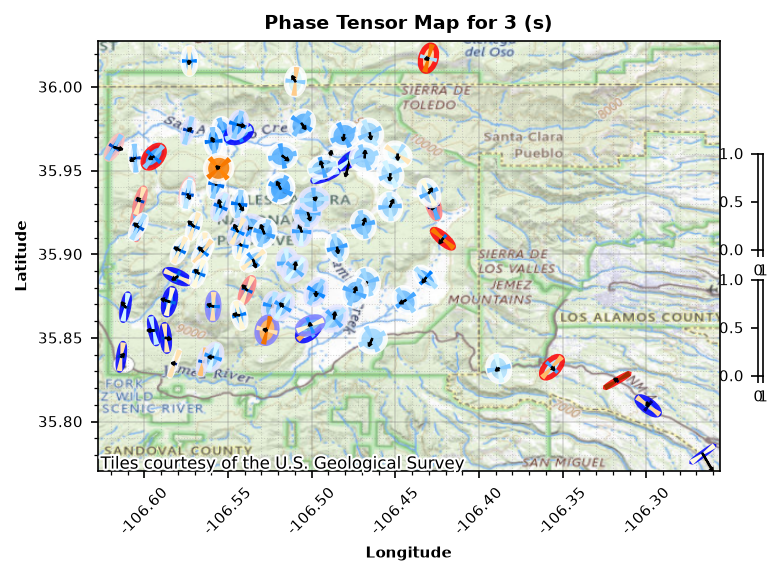

In [3]:
ptm = md.plot_phase_tensor_map(
    backend="matplotlib",
    ellipse_size=0.008,
    arrow_size=.01,
    arrow_head_width=0.0015,
    arrow_head_length=0.0015,
    arrow_lw= 0.00025,
    plot_tipper="yr", # to plot imaginary arrows use 'yri' or 'yi'
    x_pad=0.01,
    y_pad=0.01,
    plot_period=3,
    phase_limits=(0, 90),
    skew_limits=(-6, 6),
    skew_step=2
)

### 

### Apparent Resistivity and Phase Maps

Apparent resistivity and phase maps provide a nice qualitative look at subsurface resistivity structures and can highlight questionable stations prior to modeling.  We are still plotting results from the conductive block.  Here we are plotting the $xy$ and $yx$ components of the impedance tensor as well as the determinant, which is an average of all components.  Note the shape of the conductive anomaly in each component.  

The $xy$ component (electric north and magnetic east) images a conductive block that is stretched east-west, whereas the $yx$ component (electric east and magnetic north) images the conductive block stretched north-south, and the determinant as the original symmetrical shape.  The elongation is due to charge build up on the edge perpendicular to current flow which reduces the amount of current going through the body making it appear the body is elongated orthogonal to the direction of current flow.  This simple example demonstrates the need to understand the physics controlling the electromagnetic waves in the subsurface.  Note that modeling will take into account the physics to provide a physically based resistivity model, but nontheless understanding subsurface charges and electrical currents is beneficial to qualitatively interpret your data.  

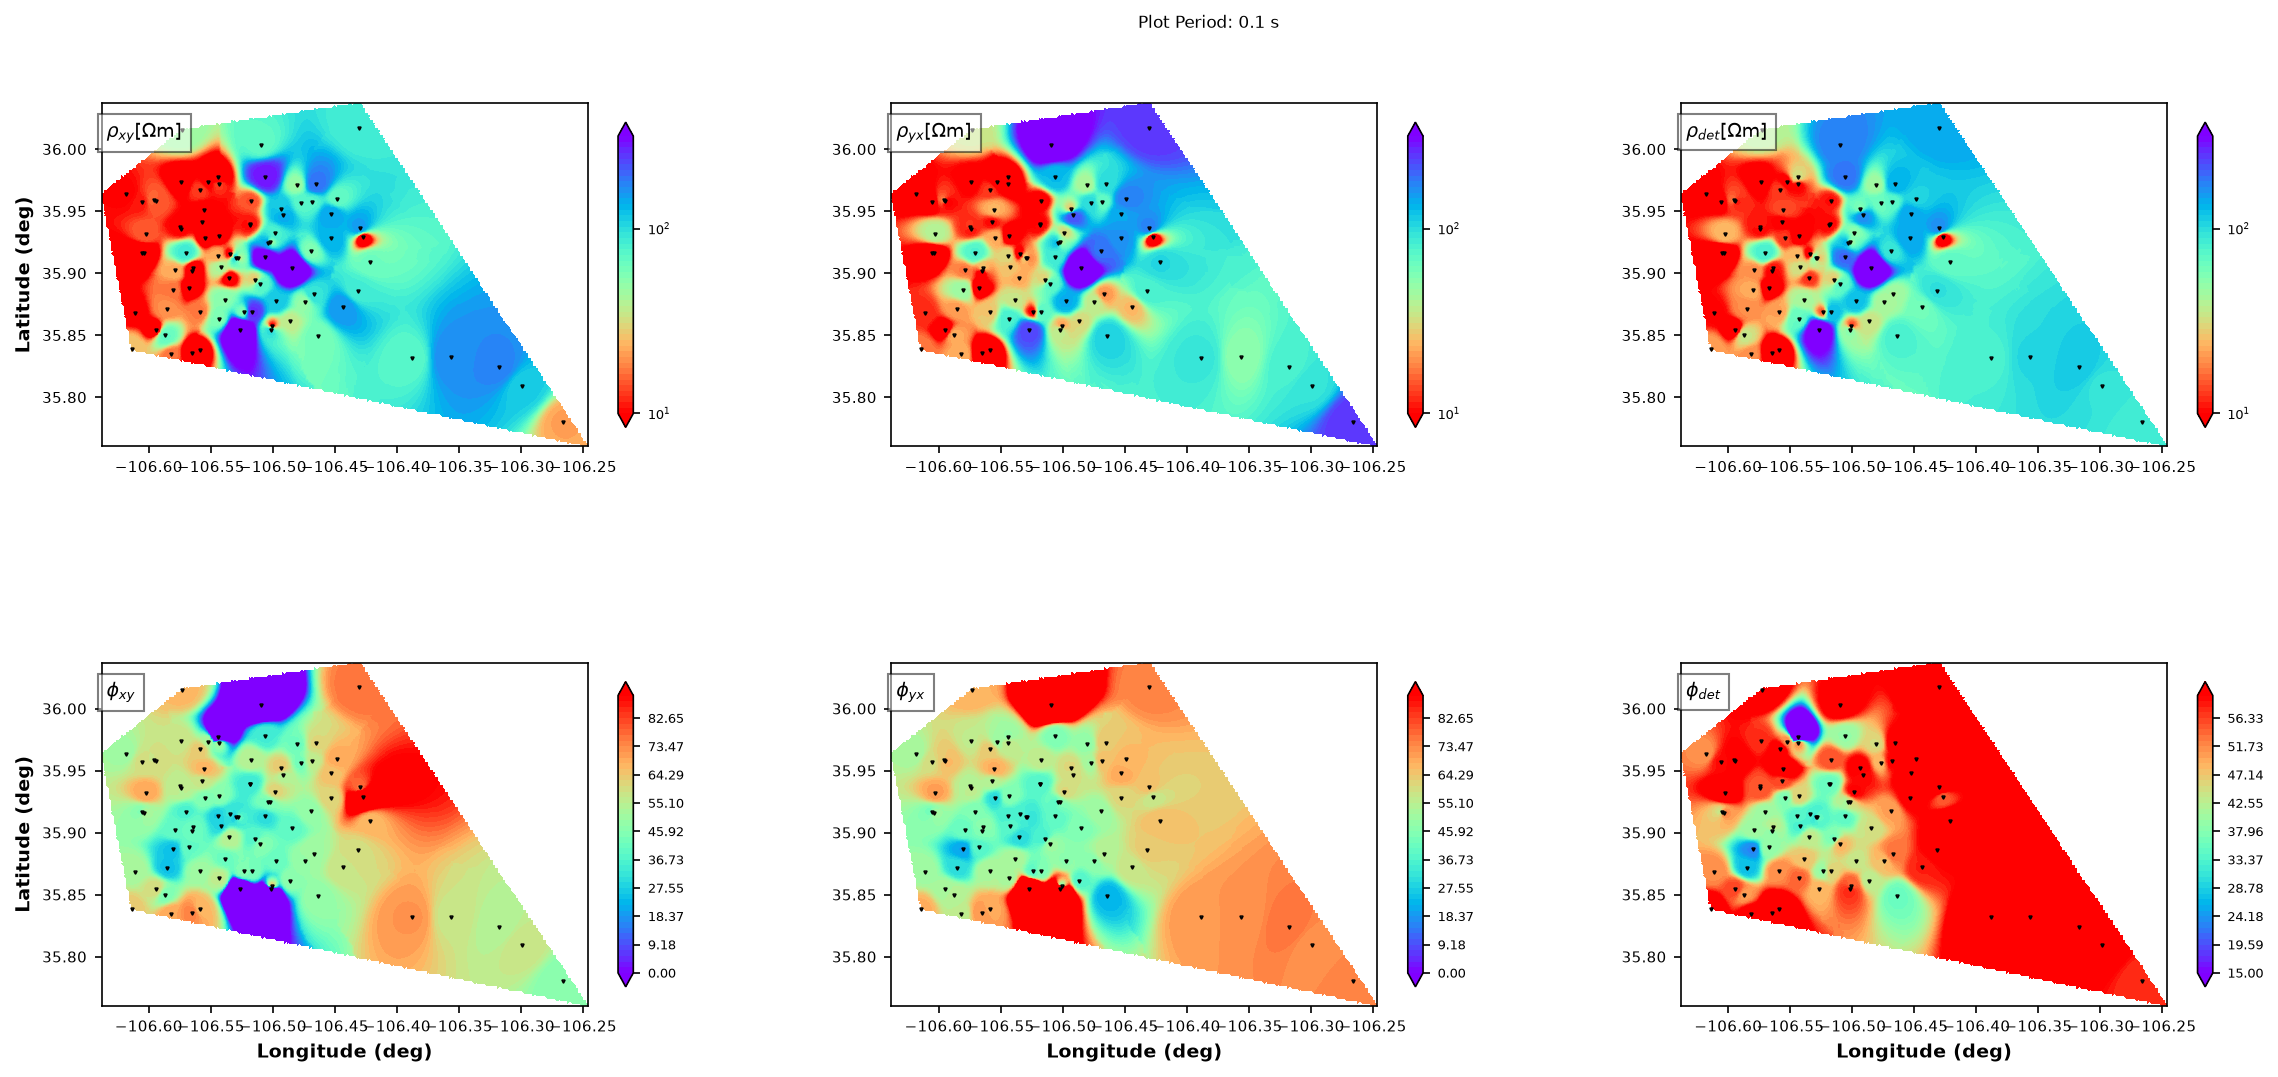

In [4]:
arp = md.plot_resistivity_phase_maps(
    backend="matplotlib",
    plot_period=0.1,
    marker_size=1.2,
    plot_xx=False,
    plot_xy=True,
    plot_yx=True,
    plot_yy=False,
    plot_det=True,
    cmap_limits={
        "res_xx": (-1, 2),
        "res_xy": (1, 2.5),
        "res_yx": (1, 2.5),
        "res_yy": (-1, 2),
        "res_det": (1, 2.5),
        "phase_xx": (-180, 180),
        "phase_xy": (0, 90),
        "phase_yx": (0, 90),
        "phase_yy": (-180, 180),
        "phase_det": (15, 60),
    },
    subplot_wspace=.3,
    subplot_hspace=.1,
    fig_size=(18, 8),

)

### Phase Tensor Pseudosection
Here we will plot the phase tensors as a function of period along an east-west profile.  

The phase tensor pseudosection provides information as a function of period, a proxy for depth. Each ellipse and induction vector is plotted in map view where up is North and the right is East.  The ellipse elongate east-west near the edge of the conductor but inside stay circular.  Similarly, the induction vectors point towards the conductor.    

In [6]:
end_point_01 = {"latitude": 35.95, "longitude": -106.2}
end_point_02 = {"latitude": 35.95, "longitude": -106.7}

# the syntax is (lon1, lat1, lon2, lat2, distance from profile in meters)
profile_line = md.get_profile(end_point_01["longitude"], end_point_01["latitude"], end_point_02["longitude"], end_point_02["latitude"], 1000)


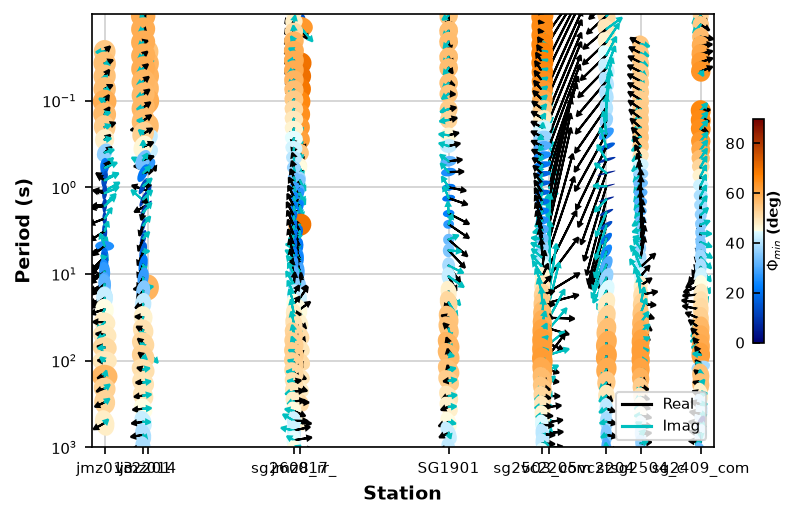

In [8]:
pts = profile_line.plot_phase_tensor_pseudosection(
    backend="matplotlib",
    y_stretch=2000,
    x_stretch=1,
    plot_tipper="yri",
    ellipse_size=600,
    arrow_size=1500,
    arrow_head_length=100,
    arrow_head_width=100,
)

### Apparent Resistivity and Phase Pseudosection

Here we will plot the profile as a pseudosection as a function of period similar to the phase tensors. As with the map view the conductive body appears to be elongated perpendicular to current flow, and the $yx$ mode appears to be more conductive.  Note that in the apparent resistivity the body seems to be imaged all the way down to the longest periods.  This is caused by the volumetric effect of the apparent resistivity.

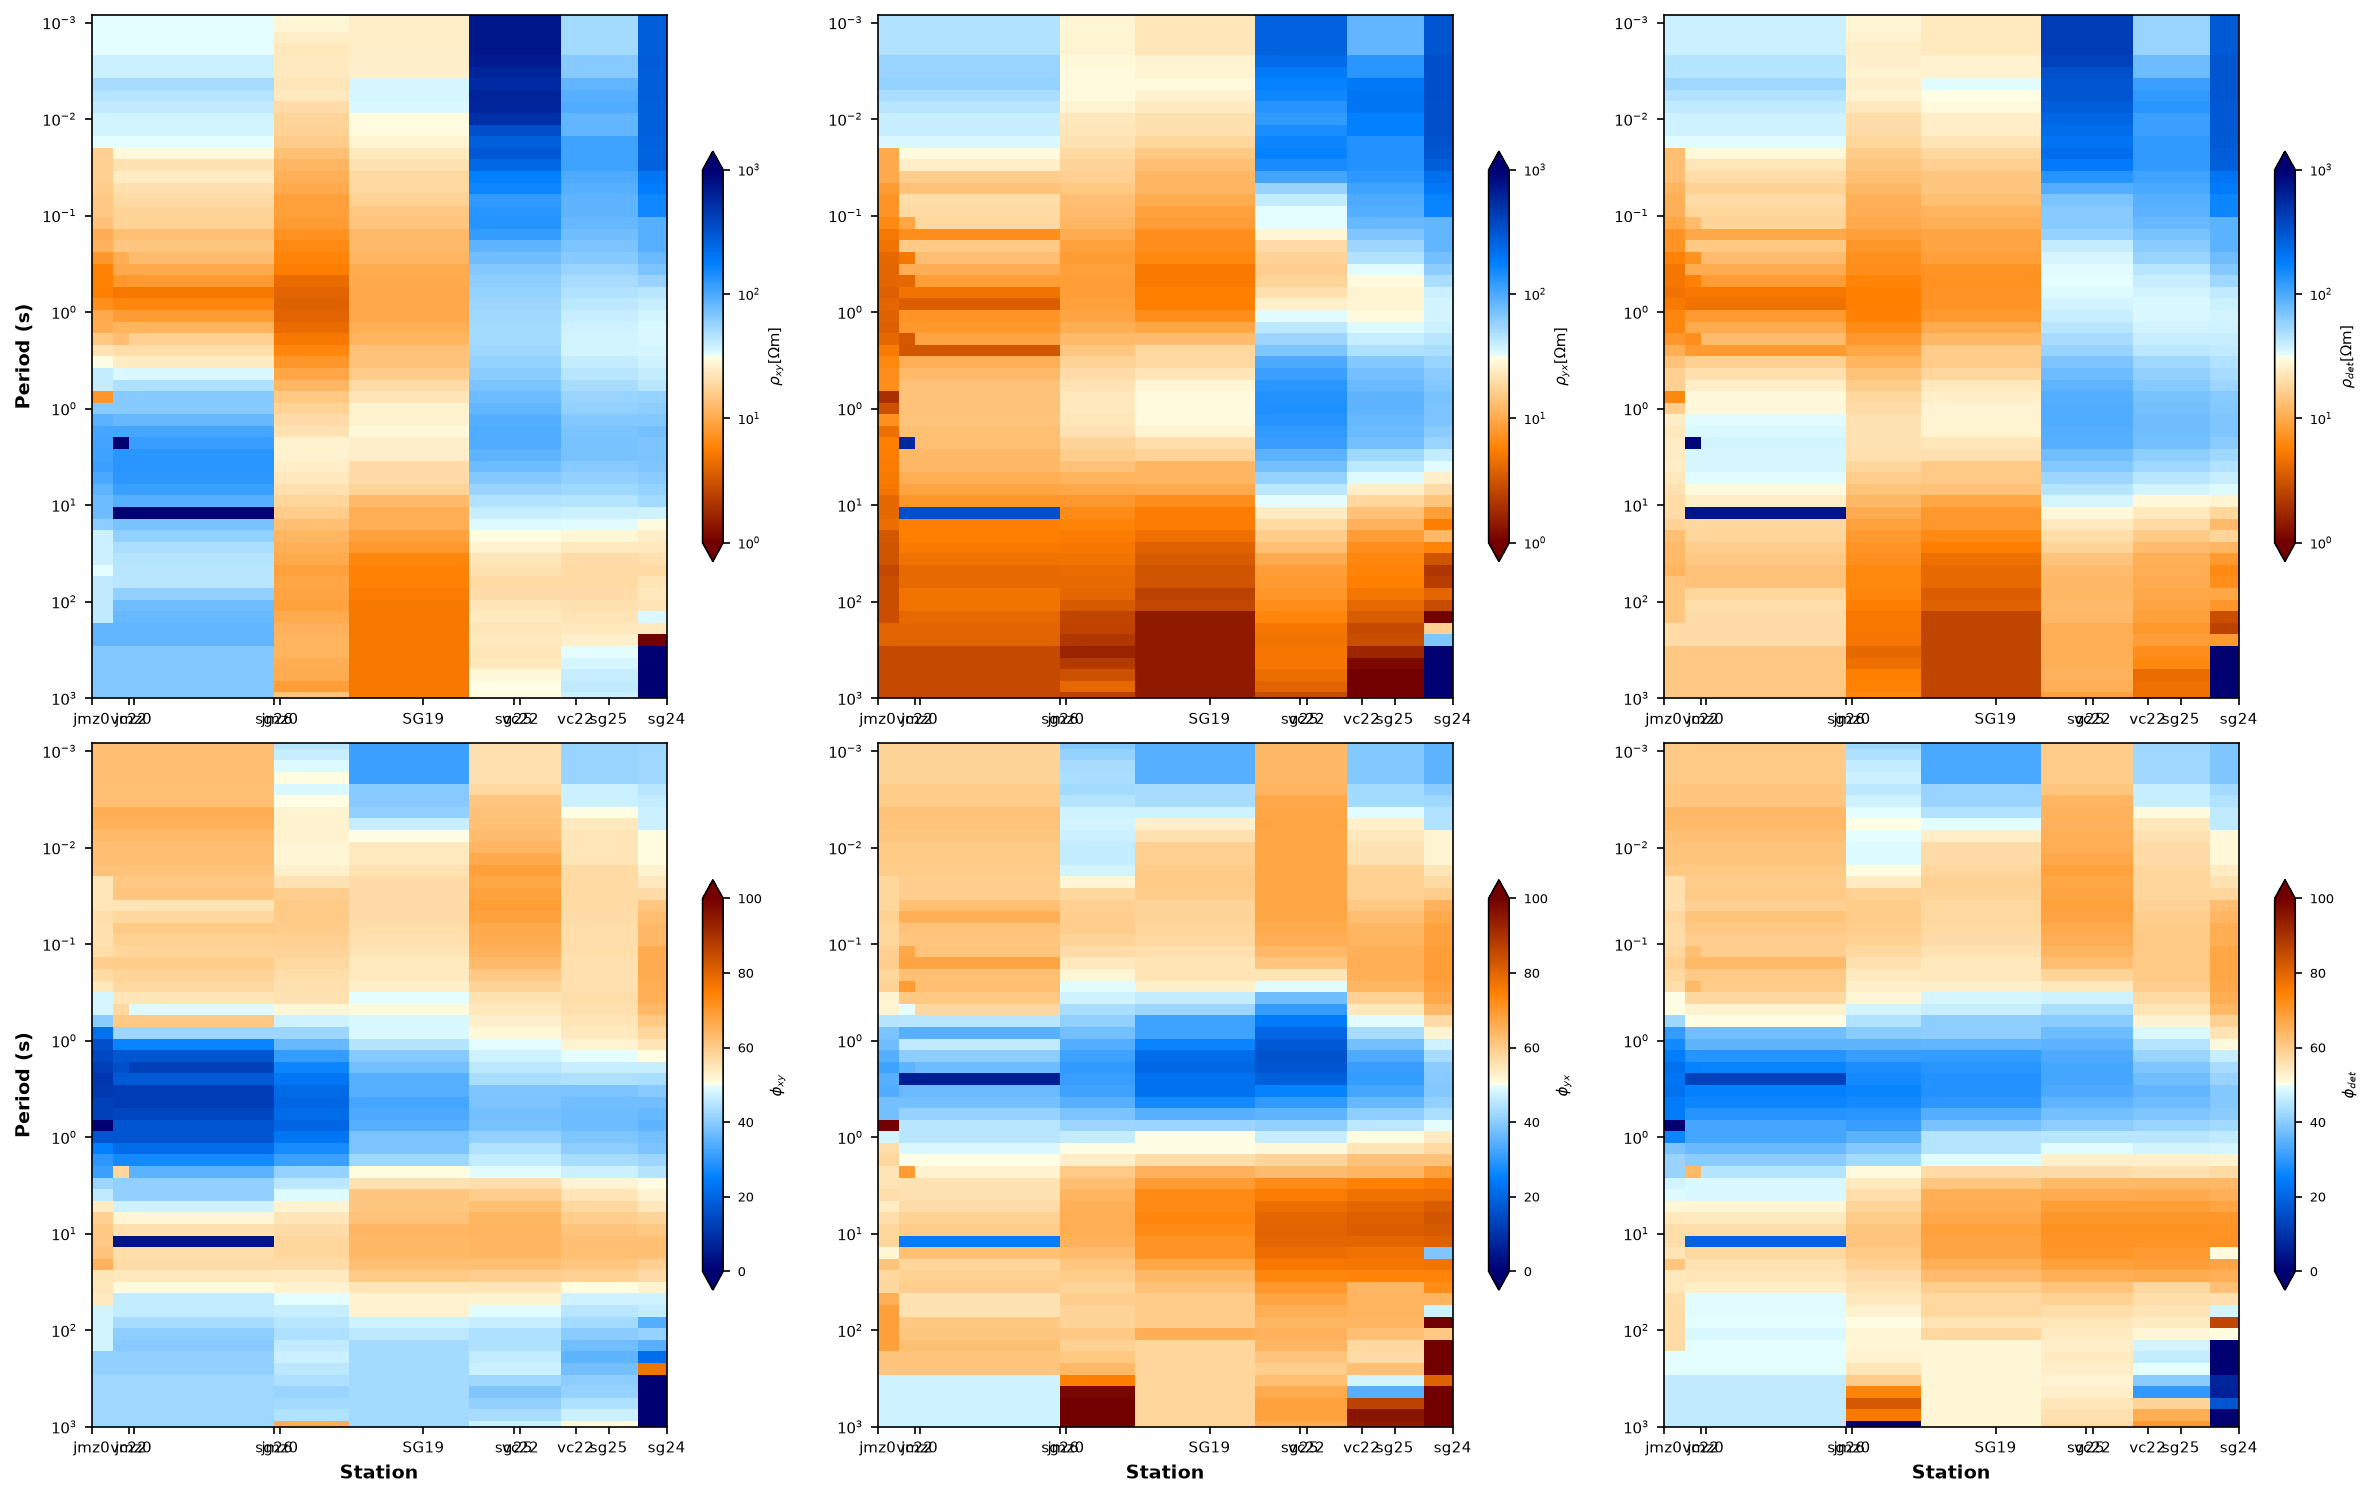

In [9]:
aps = profile_line.plot_resistivity_phase_pseudosections(
    backend="matplotlib",
    y_stretch=2500, plot_det=True, fig_size=(16, 10)
)

### Geoelectric Strike

An important parameter to estimate is the geoelectric strike direction, which aligns with the preferred direction of current flow.  The geoelectric strike direction can change with period and position.  Often in the near surface geoelectric strike mirrors geologic structures, but in the mid- and lower-crust strike directions are effected by more subtle physical properties such as rheologic structure and fabric.  Understanding geoelectric strike can help determine the dimensional space in which to model your data.

Here we are estimating geoelectrical strike from invariants of the impedance tensor [Weaver et al. (2000)](https://doi.org/10.1046/j.1365-246x.2000.00089.x), azimuth of the phase tensor [Caldwell et al. (2004)](https://doi.org/10.1111/j.1365-246X.2004.02281.x), and the induction vectors.  Note that the induction vectors are often orthogonal to the geoelectric strike as they point towards strong conductors, but not always the case as seen below.

Also note, estimation of geoelectrical strike has a 90 degree ambiguity.  That is if you try to minimize impedance tensor by tracing around 360 degrees you will get 4 peaks instead of the normal 2.  This can be observed in the plots below.  One way to try to rectify which angle is the strike direction is compare impedance strike with induction vector strike.  At periods longer than 1 second there is a strike in the east-west and the north-south in the impedance, but in the induction vectors the strike is mainly north-south, suggesting the dominate strike direction is east-west.  Now this example is bias because of the station coverage, perhaps a better example would be to look at the profile strike angles.  

26:06:28T08:46:16 | INFO | line:769 |mtpy.imaging.plot_strike | _plot_per_period | Note: North is assumed to be 0 and the strike angle is measuredclockwise positive.


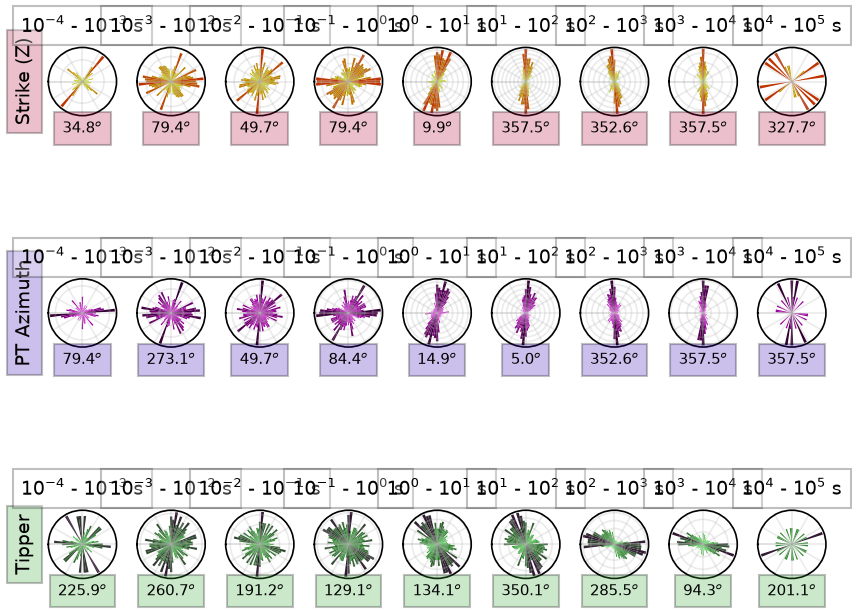

In [10]:
plot_strike = md.plot_strike(plot_type=1, backend="matplotlib",)


### Profile Geoelectrical Strike

A more demonstrative example of geoelectrical strike changing with period is along the profile.  In this case the induction vectors and the geoelectric strike are in the same direction at longer periods, but at shorter periods, where the conductive body is they are orthogonal.  

26:06:28T08:46:41 | INFO | line:769 |mtpy.imaging.plot_strike | _plot_per_period | Note: North is assumed to be 0 and the strike angle is measuredclockwise positive.


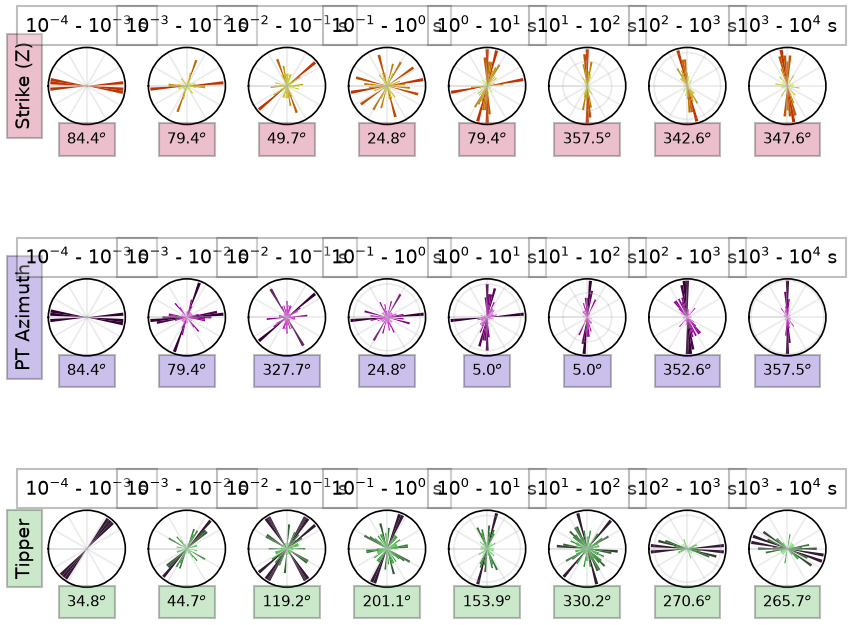

In [11]:
profile_plot_strike = profile_line.plot_strike(plot_type=1, backend="matplotlib",)

With all this information just from the transfer functions preliminary interpretations can be made and a determination of the correct dimensional space to model the data can be assumed.  



# Modeling and Inversion

Modeling the data in the correct dimensional space is of critical importance.  These days with compute power and resources 3D is the best option because as we have seen MT data inherently contains directional information about subsurface resistivity structures.  1D and 2D modeling have their place but should be used with caution.  The classic example is from Krafla, Iceland where 1D modeling missed the conductive zone of melt hit when drilling into what was thought to be a resistive zone. This was later rectified by 3D modeling [](https://doi.org/10.1093/gji/ggz427).  1D and 2D modeling are much faster, but good things come to those who wait for a 3D inversion to finish. 

Here we will demonstrate some simple 1D, 2D, and 3D modeling using [Simpeg](https://doi.org/10.1016/j.cageo.2017.06.018).  Recipes for using `simpeg` are included in `mtpy-v2` except for 3D. 

### 1D Inversion

In this example we will invert in 1D a station that sits directly over the conductive body.

In [12]:
station = md.get_station("SAGE2026/sg2602", as_mt=True)

Set some error floors to the data. Here we are setting the error to be 3% of the impedance tensor elements.  Setting an error floor is common in inversion as the data errors maybe too small to fit appropriately.  The error floors are what dictates how close the inversion will try to fit the original data.  If the data are nice and smooth small error floors may be appropriate, if the data are noisy then some points may have large error to downweight the importance of fitting the bad data point.  The point is that when doing an inversion be mindful of the data weighting through the assignment of data errors. 

In [13]:
station.compute_model_z_errors(error_value=.03, error_type="percent")

Compute a 1D inversion using `simpeg`.  For more information on parameters associated with the inversion see [simpeg documentation](https://simpeg.xyz/).

Here we are computing a smooth 1D inversion of the impedance tensor determinant.  The determinant is basically an average of the impedance tensor elements and is a safe mode to invert in 1D.  

In the plots below, the first plot is the Tikhonov curve showing the model roughness on the x-axis versus data misfit on the y-axis.  In general this will take an *L* shape, where the elbow is the optimum model that fits the data according to misfit and a relatively smooth model.  Here the inversion stops when it hits the target misfit.

The second plot is the 1D resistivity model as a function of depth along with the model fit to the apparent resistivity and phase of the impedance determinant.  The model fits the data well and has a similar shape to what would be expected.  A resistive near surface, the conductive block, and into a half-space of 10 $\Omega \cdot m$.

You can try different norms and other parameters to see how the model changes.  Setting the norms to be 0 will produce a blocky model.  

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 128.0



Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  9.44e+02  8.51e+03  0.00e+00  8.51e+03                                 
   1  9.44e+02  1.20e+03  3.86e-04  1.20e+03    3.25e+03      0              
   2  4.72e+02  1.95e+02  4.41e-03  1.97e+02    5.79e+02      0   Skip BFGS  
   3  2.36e+02  1.53e+02  1.24e-02  1.55e+02    1.09e+02      0              
   4  1.18e+02  6.91e+01  1.37e-02  7.08e+01    7.92e+01      1              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 8.3229e+01 <= tolF*(1+|f0|) = 8.5107e+02
0 : |xc-x_last| = 7.4611e+00 <= tolX*(1+|x0|) = 4.7281e+00
0 : |proj(x-g)-x|    = 7.9243e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.9243e+01 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      20    <= iter

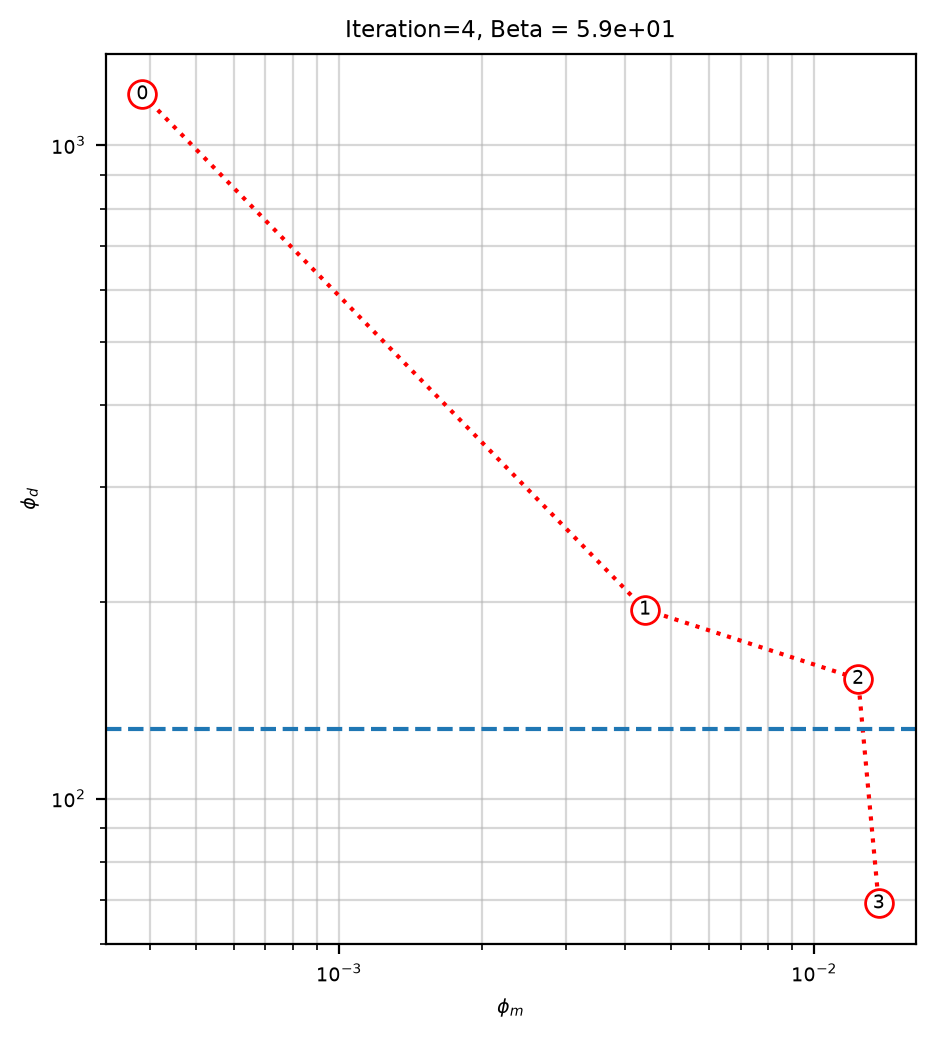

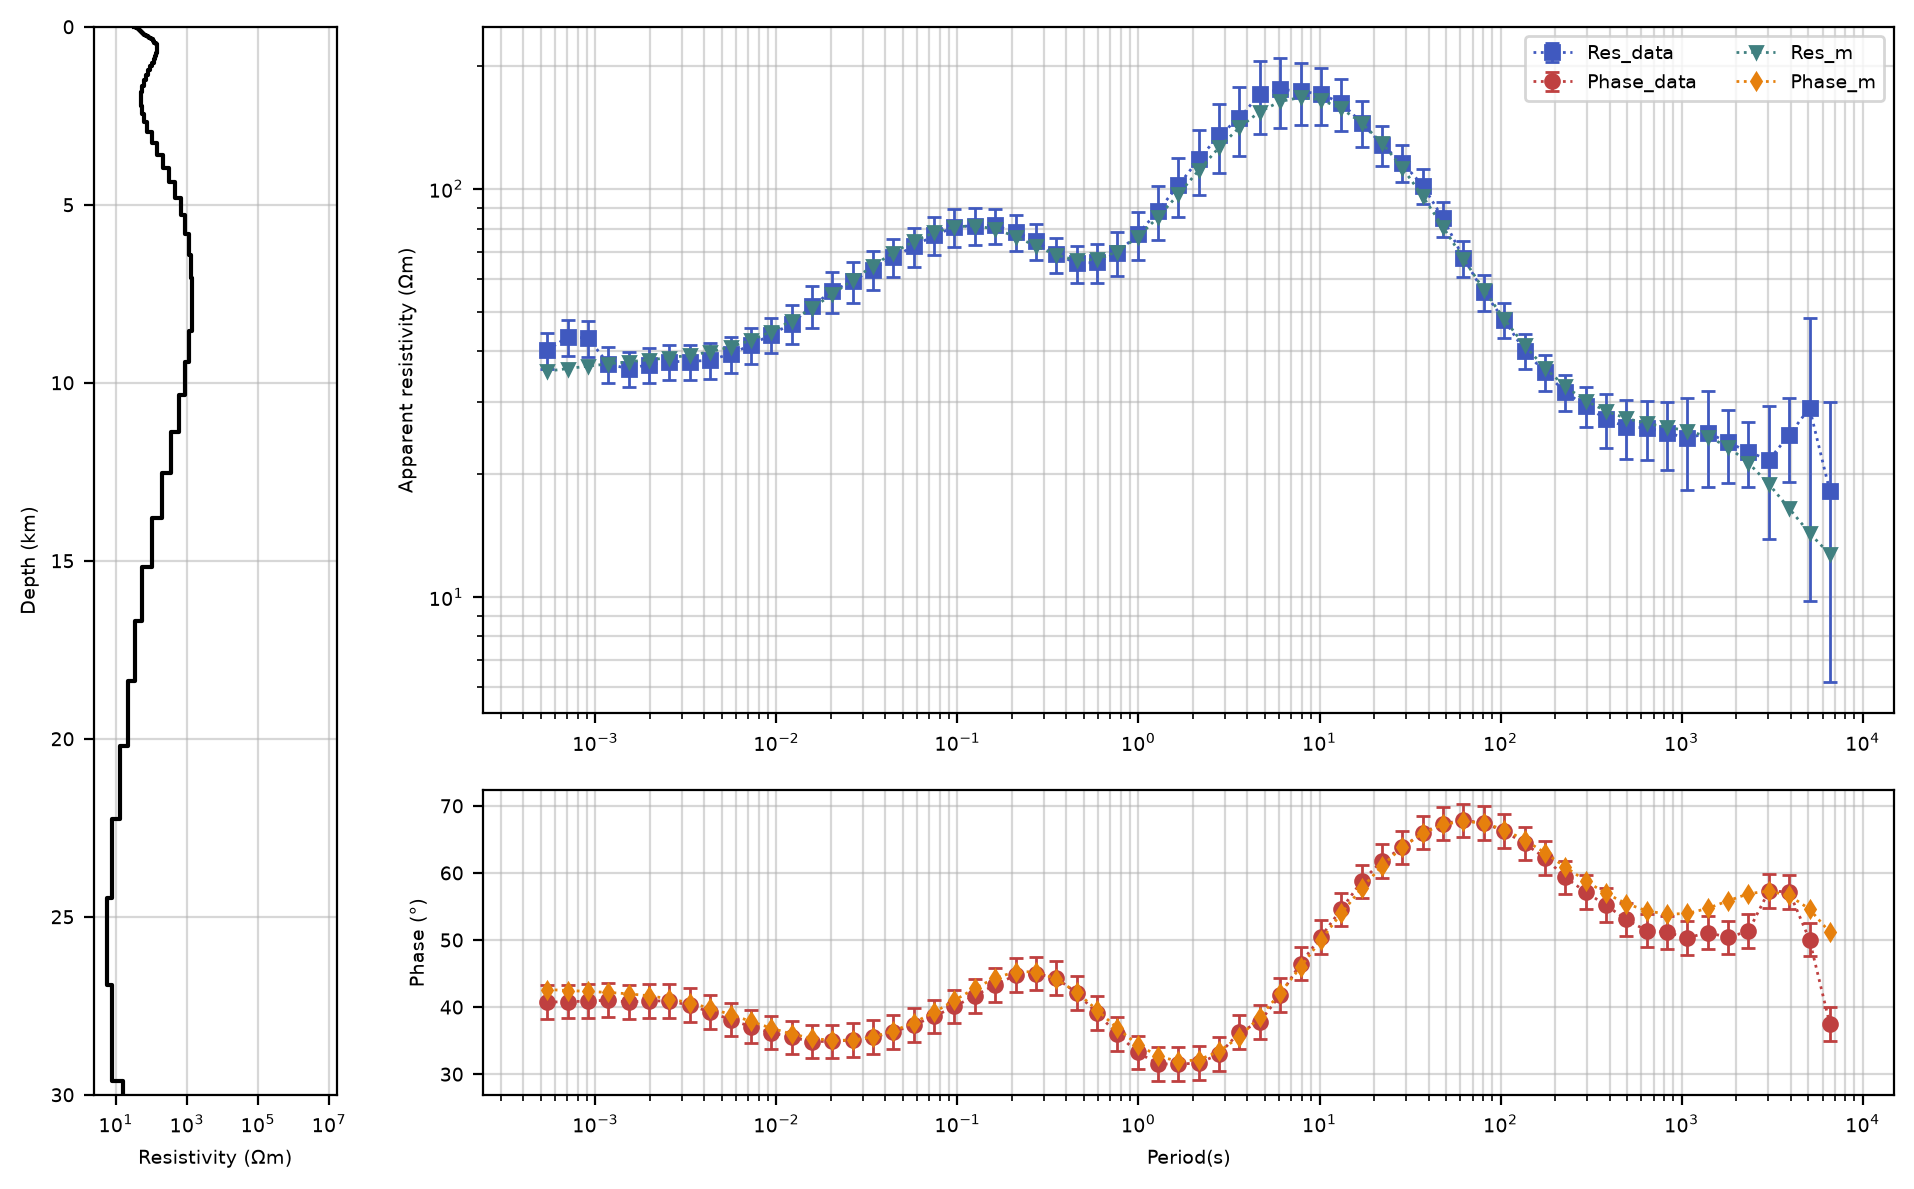

In [15]:
inv_1d = station.to_simpeg_1d(
    alpha_s=1e-15,             # mulitplier constant to the smallness term.  The small the more smooth  
    p_z=2,                     # norm in the z-direction 2: L2-norm, 1: L1-norm, 0: blocky model
    p_s=2,                     # for the smallness 2: L2-norm, 1: L1-norm, 0: blocky model
    maxIter=20,                # maximum number of iterations
    z_factor=1.1,              # factor to increase cell thickness with depth  
    n_layers=100,              # number of layers
    **{"y_scale": "linear", "y_limits": (30, 0)} # plotting directives
)

#### Run a blocky 1D model

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.94e+00  8.51e+03  0.00e+00  8.51e+03                                 
   1  1.94e+00  1.48e+03  3.06e+02  2.08e+03    4.13e+03      0              
   2  9.72e-01  6.08e+02  6.64e+02  1.25e+03    5.77e+02      0   Skip BFGS  
   3  4.86e-01  3.79e+02  8.51e+02  7.93e+02    2.49e+02      0              
   4  2.43e-01  2.71e+02  1.11e+03  5.41e+02    1.07e+02      0   Skip BFGS  
   5  1.21e-01  1.90e+02  1.55e+03  3.78e+02    6.43e+01      0   Skip BFGS  
   6  6.07e-02  1.24e+02  2.32e+03  2.65e+02    6.60e+01      0              
Reached starting chifact with l2-norm regularization: Start IRLS steps...
irls_threshold 2.8848667698488866
   7  6.07e-02  1.94e+02  2.65e+03  3.55e+02    1.38e+02      0         

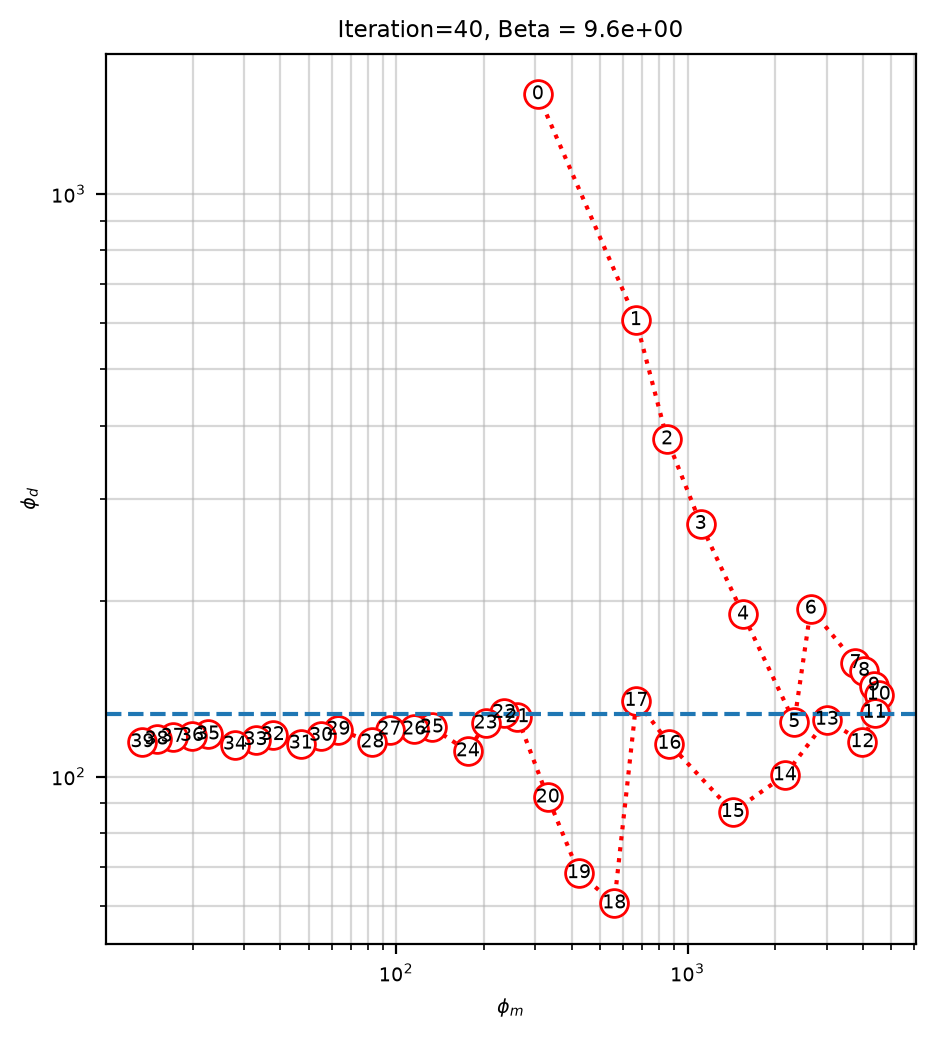

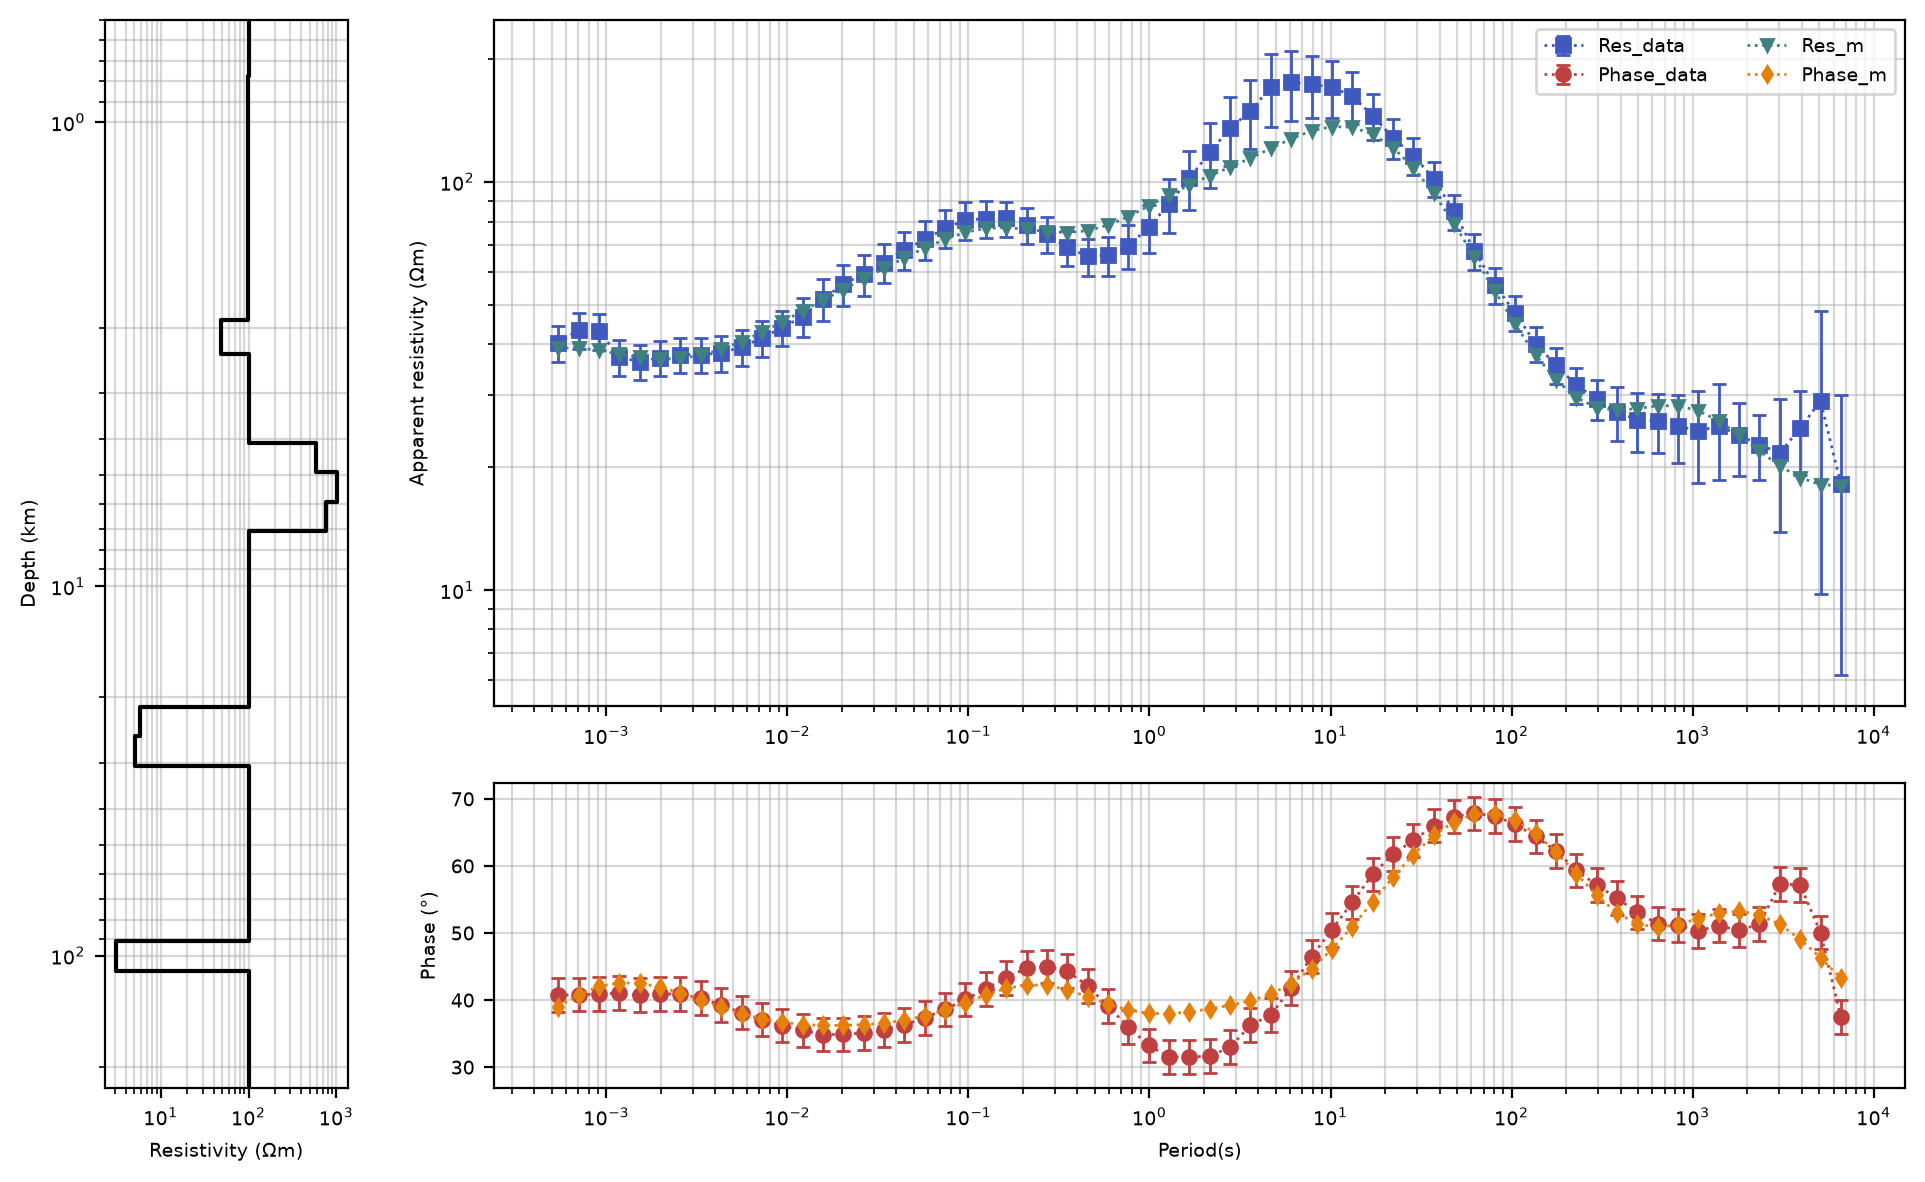

In [16]:
inv_1d_block = station.to_simpeg_1d(mode="det", **{"p_s": 0, "p_z": 0, "use_irls": True, "alpha_s": 1e-2})

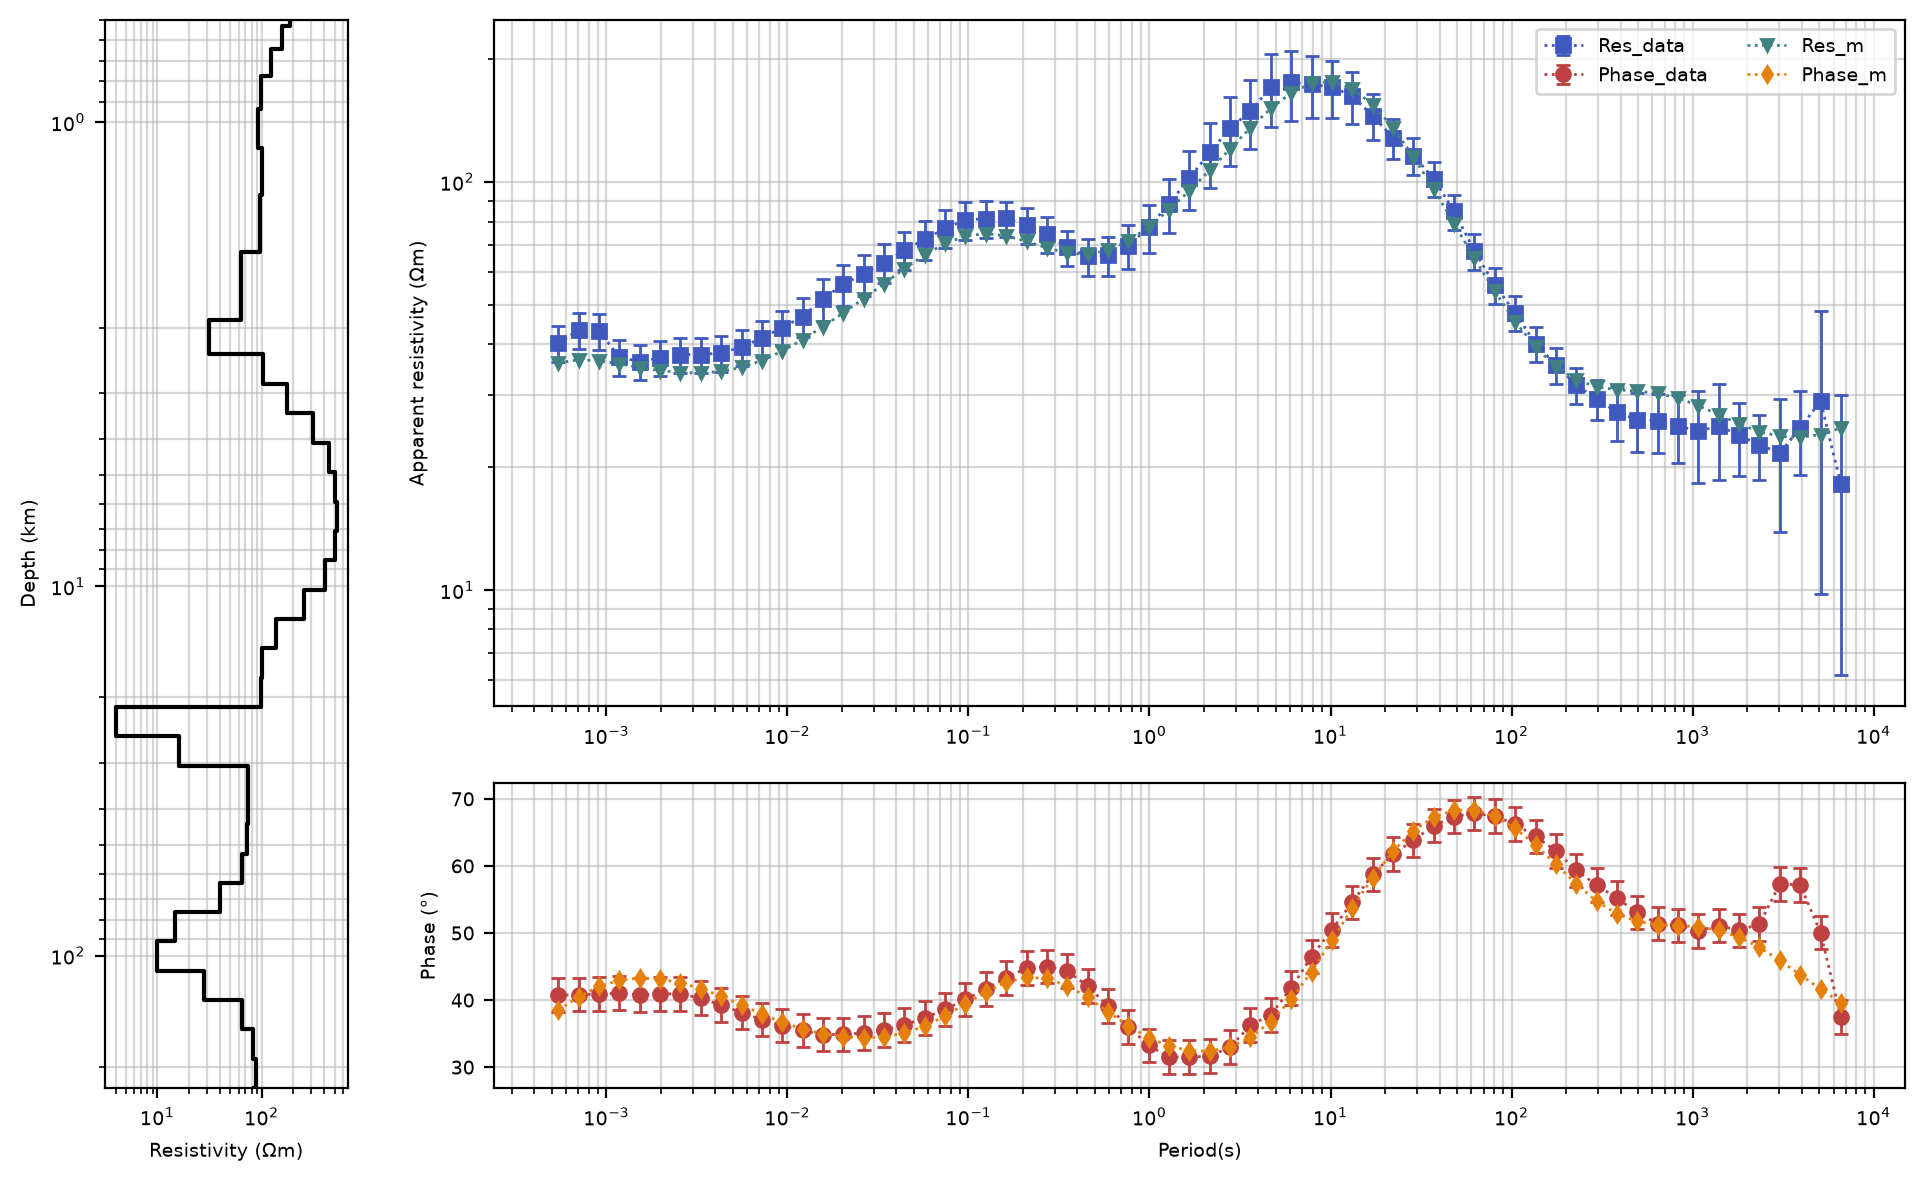

In [18]:
plot_block = inv_1d_block.plot_response(13)